In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
""" 
Sampling rate: 1000 Hz
We want to preserve frequencies below 50 Hz
We want strong attenuation above 100 Hz
We want to compare how different filter families make that transition.
"""

' \nSampling rate: 1000 Hz\nWe want to preserve frequencies below 50 Hz\nWe want strong attenuation above 100 Hz\nWe want to compare how different filter families make that transition.\n'

In [3]:
fs = 1000
passband = 50
stopband = 100
order = 4

# Butterworth
b_butter, a_butter = signal.butter(
    order,
    passband,
    btype = 'low',
    fs=fs
)

#Chebyshev Type I
b_cheby1, a_cheby1 = signal.cheby1(
    order,
    1, #1 dB passband ripple
    passband,
    btype='low',
    fs=fs
)

#Chebyshev Type II
b_cheby2, a_cheby2 = signal.cheby2(
    order,
    40, # 40dB stopband attentuation
    passband,
    btype='low',
    fs=fs
)

# Elliptic
b_ellip, a_ellip = signal.ellip(
    order,
    1, #1dB passband ripple
    40, #40 dB stopband attenuation
    passband,
    btype = 'low',
    fs=fs
)

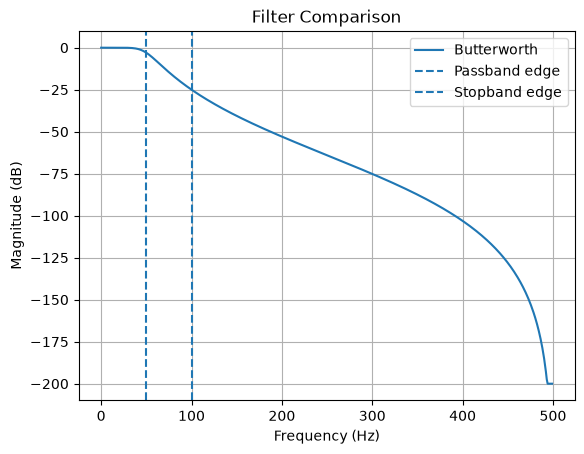

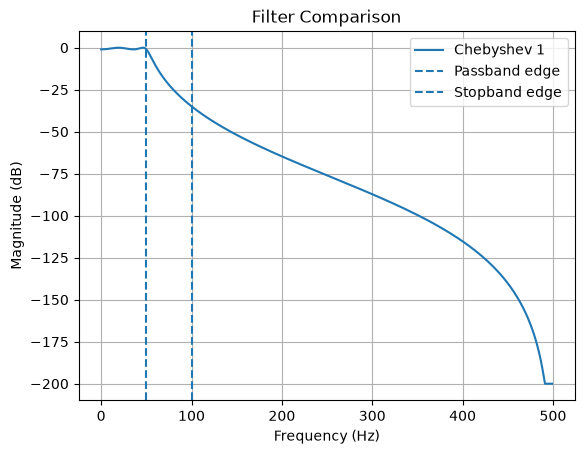

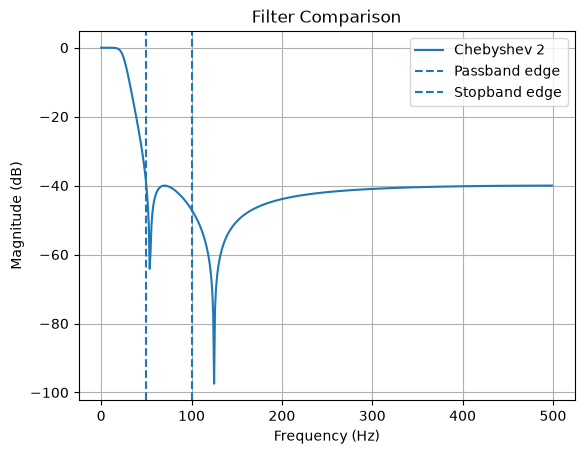

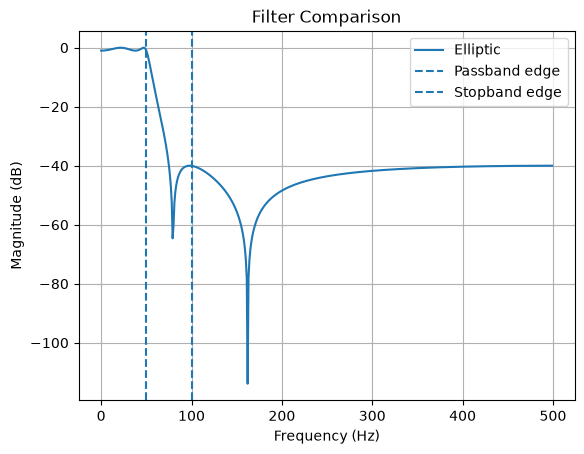

In [4]:
# make a dictionary of filters to loop through
filters = {
    "Butterworth": (b_butter, a_butter),
    "Chebyshev 1": (b_cheby1, a_cheby1),
    "Chebyshev 2": (b_cheby2, a_cheby2),
    "Elliptic": (b_ellip, a_ellip)
}

for filter, (b, a) in filters.items():
    w, h = signal.freqz(b, a, fs=fs)
    plt.plot(w, 20*np.log10(np.maximum(np.abs(h), 1e-10)), label = filter)
    plt.axvline(passband, linestyle = '--', label = 'Passband edge')
    plt.axvline(stopband, linestyle = '--', label = 'Stopband edge')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.title('Filter Comparison')
    plt.legend()
    plt.grid()
    plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000

passband = 50
stopband = 100

passband_ripple = 1
stopband_attenuation = 40


# Butterworth
N_butter, Wn_butter = signal.buttord(
    wp=passband,
    ws=stopband,
    gpass=passband_ripple,
    gstop=stopband_attenuation,
    fs=fs
)

# Chebyshev Type I
N_cheby1, Wn_cheby1 = signal.cheb1ord(
    wp=passband,
    ws=stopband,
    gpass=passband_ripple,
    gstop=stopband_attenuation,
    fs=fs
)

# Chebyshev Type II
N_cheby2, Wn_cheby2 = signal.cheb2ord(
    wp=passband,
    ws=stopband,
    gpass=passband_ripple,
    gstop=stopband_attenuation,
    fs=fs
)

# Elliptic
N_ellip, Wn_ellip = signal.ellipord(
    wp=passband,
    ws=stopband,
    gpass=passband_ripple,
    gstop=stopband_attenuation,
    fs=fs
)


print("Butterworth order:", N_butter)
print("Chebyshev I order:", N_cheby1)
print("Chebyshev II order:", N_cheby2)
print("Elliptic order:", N_ellip)

Butterworth order: 8
Chebyshev I order: 5
Chebyshev II order: 5
Elliptic order: 4


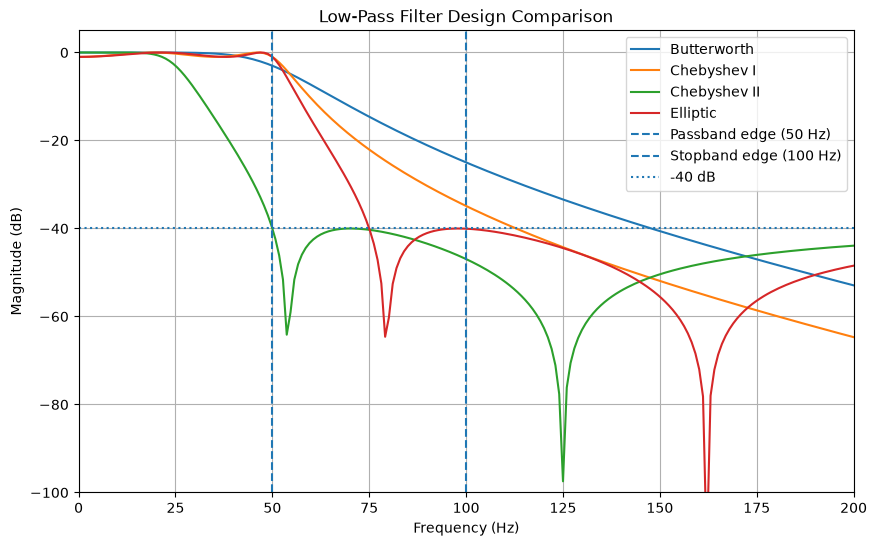

In [6]:
filters = {
    "Butterworth": (b_butter, a_butter),
    "Chebyshev I": (b_cheby1, a_cheby1),
    "Chebyshev II": (b_cheby2, a_cheby2),
    "Elliptic": (b_ellip, a_ellip)
}

plt.figure(figsize=(10, 6))

for name, (b, a) in filters.items():

    w, h = signal.freqz(b, a, fs=fs)

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-10)
    )

    plt.plot(w, magnitude_db, label=name)

plt.axvline(
    passband,
    linestyle='--',
    label='Passband edge (50 Hz)'
)

plt.axvline(
    stopband,
    linestyle='--',
    label='Stopband edge (100 Hz)'
)

plt.axhline(
    -stopband_attenuation,
    linestyle=':',
    label='-40 dB'
)

plt.xlim(0, 200)
plt.ylim(-100, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Low-Pass Filter Design Comparison")
plt.legend()
plt.grid()
plt.show()

In [7]:
# Design filters using the calculated orders

b_butter, a_butter = signal.butter(
    N_butter,
    Wn_butter,
    btype='low',
    fs=fs
)

b_cheby1, a_cheby1 = signal.cheby1(
    N_cheby1,
    passband_ripple,
    Wn_cheby1,
    btype='low',
    fs=fs
)

b_cheby2, a_cheby2 = signal.cheby2(
    N_cheby2,
    stopband_attenuation,
    Wn_cheby2,
    btype='low',
    fs=fs
)

b_ellip, a_ellip = signal.ellip(
    N_ellip,
    passband_ripple,
    stopband_attenuation,
    Wn_ellip,
    btype='low',
    fs=fs
)

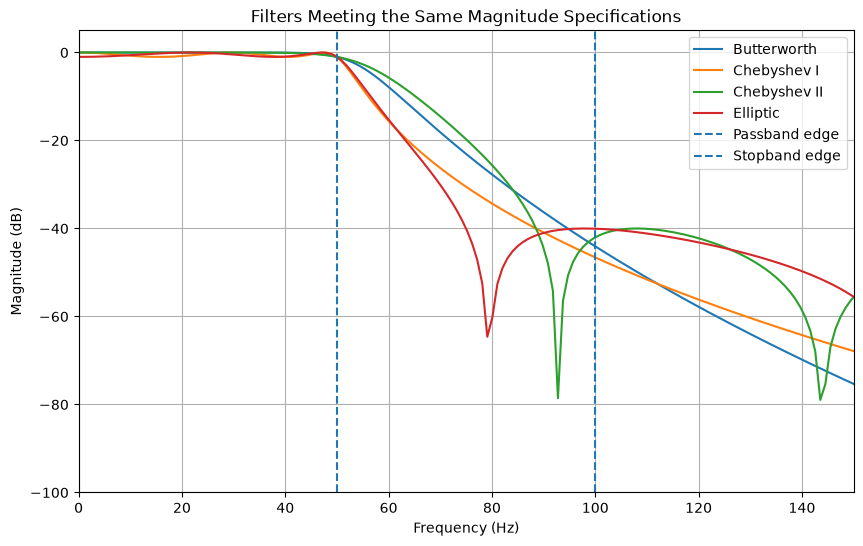

In [8]:
filters = {
    "Butterworth": (b_butter, a_butter),
    "Chebyshev I": (b_cheby1, a_cheby1),
    "Chebyshev II": (b_cheby2, a_cheby2),
    "Elliptic": (b_ellip, a_ellip)
}

plt.figure(figsize=(10, 6))

for name, (b, a) in filters.items():

    f, h = signal.freqz(b, a, fs=fs)

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-10)
    )

    plt.plot(f, magnitude_db, label=name)

plt.axvline(passband, linestyle='--', label='Passband edge')
plt.axvline(stopband, linestyle='--', label='Stopband edge')

plt.xlim(0, 150)
plt.ylim(-100, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Filters Meeting the Same Magnitude Specifications")
plt.legend()
plt.grid()
plt.show()

In [9]:
for name, (b, a) in filters.items():

    f, h = signal.freqz(b, a, fs=fs)
    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(h), 1e-10)
    )

    passband_mask = f <= passband
    stopband_mask = f >= stopband

    worst_passband = np.min(magnitude_db[passband_mask])
    worst_stopband = np.max(magnitude_db[stopband_mask])

    print(f"\n{name}")
    print(f"Worst passband magnitude: {worst_passband:.2f} dB")
    print(f"Worst stopband magnitude: {worst_stopband:.2f} dB")


Butterworth
Worst passband magnitude: -0.94 dB
Worst stopband magnitude: -44.50 dB

Chebyshev I
Worst passband magnitude: -1.00 dB
Worst stopband magnitude: -46.89 dB

Chebyshev II
Worst passband magnitude: -0.96 dB
Worst stopband magnitude: -40.00 dB

Elliptic
Worst passband magnitude: -1.00 dB
Worst stopband magnitude: -40.00 dB
